# Baseline Model

## Package Import & Path Settings

In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import hashlib
from pathlib import Path
from collections import defaultdict
import time
from PIL import Image, UnidentifiedImageError
import gc

# pytorch
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from torch.utils.data import DataLoader
from torchvision import transforms
from torch import nn
import torch

# data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit

# baseline models
from sklearn.dummy import DummyClassifier
from sklearn.metrics import log_loss

# others
from concurrent.futures import ThreadPoolExecutor
from src.dataset import load_filtered_imagefolder, rgba_to_rgb_with_bg, ds_test_split
from tqdm.auto import tqdm
from src.utils import plot_hist, plot_confusion_matrix_and_report, profile_dataloader, display_model_info
from src.training import load_checkpoint, get_last_checkpoint, get_last_checkpoint, save_checkpoint
from src.utils import profile_dataloader_grid_search, build_profile_heatmap_data

# path settings
from src import MODELS_DIR, PARAMS_PATH, SEED, PET_IMAGES_DIR, PROJECT_ROOT, get_device
DEVICE = get_device()
CKPT_DIR = PROJECT_ROOT / "outputs" / "checkpoints"
print(f'Device: {DEVICE}')
print(f'MODELS_DIR: {MODELS_DIR}')
print(f'PARAMS_PATH: {PARAMS_PATH}')
print(f'SEED: {SEED}')
print(f'PET_IMAGES_DIR: {PET_IMAGES_DIR}')
print(f'CKPT_DIR (Check Point): {CKPT_DIR}')

# project constants
label = {0:'cat', 1:'dog'}
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)
SAMPLE_SIZE = 256


Device: cuda
MODELS_DIR: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\models
PARAMS_PATH: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\params
SEED: 37
PET_IMAGES_DIR: C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\data\raw\PetImages
CKPT_DIR (Check Point): C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\outputs\checkpoints


## Helper Functions

## Data Loading


In [2]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(SAMPLE_SIZE),    
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
val_tf = transforms.Compose([
    transforms.Resize(SAMPLE_SIZE),
    transforms.CenterCrop(SAMPLE_SIZE),    
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [3]:
bad_path = PET_IMAGES_DIR / 'bad_files.json'
dup_group_path = PET_IMAGES_DIR / 'duplicate_groups_exact.json'
ignore_path = PET_IMAGES_DIR / 'ignore_files_list.json'

ds_aug, excl_set = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, train_tf, rgba_to_rgb_with_bg) # the dataset with augmentation
ds, _ = load_filtered_imagefolder(PET_IMAGES_DIR, bad_path, dup_group_path, ignore_path, val_tf, rgba_to_rgb_with_bg) # the dataset without any augmentation

print(f'Dataset Loaded from {PET_IMAGES_DIR}')
print(f'Number of valid samples: {len(ds)}')
print(f'Number of samples excluded: {len(excl_set)}')

Dataset Loaded from C:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\data\raw\PetImages
Number of valid samples: 24968
Number of samples excluded: 32


### Test Data Split

Train / Test Data Split: 50%

In [4]:
idx_train, idx_test, y_train, y_test = ds_test_split(ds, 0.5, SEED, True)

## Baseline Model

A simple CNN model is constructed with PyTorch. The model consists of the following components:

**1) Feature extractor (backbone / conv stack)**
- **Conv2d** *(out_channels = 32 → 64 → 128 → 256, kernel=5, padding=2)*  
  Extract spatial features; padding keeps **H×W** unchanged **before pooling**.
- **BatchNorm2d** *(per channel)*  
  Normalizes activations using batch statistics during training; stabilizes and often speeds up convergence.
- **ReLU**  
  Adds non-linearity so the network can model complex decision boundaries.
- **MaxPool2d(2)**  
  Downsamples spatial resolution: **H, W → H/2, W/2** (done 4 times in this model).
- **AdaptiveAvgPool2d((1,1))** *(Global Average Pooling)*  
  Collapses each channel’s **H×W** feature map into **1×1**, producing a fixed-length representation.

**2) Classifier (head)**
- **Flatten**  
  Converts **(N, 256, 1, 1)** → **(N, 256)**.
- **Linear(256 → num_class)**  
  Outputs **logits** of shape **(N, num_class)** (e.g., **(N, 2)** for 2 classes).  
  *Logits are raw scores before softmax.*

---

**Shape Trace (Example)**
Assume input **x** has shape **(N, 3, H, W)**:

- After conv stack + pools: **(N, 256, H/16, W/16)**
- After AdaptiveAvgPool2d((1,1)): **(N, 256, 1, 1)**
- After flatten: **(N, 256)**
- After classifier: **(N, num_class)**

---

**Inference Helpers in This Class**
- `predict(x)`: returns **logits** (uses `no_grad()` + `eval()`).
- `predict_proba(x)`: returns **softmax probabilities** (uses `inference_mode()` + `eval()`).
- `predict_id(x)`: returns **argmax class indices** from probabilities.



In [5]:
class CNN_Clf(nn.Module):
    def __init__(self, num_class=2):
        super().__init__()
        self.feature = nn.Sequential(
            nn.Conv2d(3, 32, 5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Linear(256, num_class)

        pass   

    def forward(self, x):
        x = self.feature(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits
    
    @ torch.no_grad()
    def predict(self, x):
        self.eval()
        return self.forward(x)
    
    @ torch.inference_mode()
    def predict_proba(self, x):
        self.eval()
        return torch.softmax(self.forward(x), dim=1, dtype=torch.float32)
    
    @ torch.inference_mode()
    def predict_id(self, x):
        self.eval()
        proba = self.predict_proba(x)
        ids = torch.argmax(proba, axis=1)       
        return ids


In [6]:
model = CNN_Clf(2)
# Assuming 'model' is the CNN model instance
display_model_info(model)

Trainable parameters: 1079554
Model size: 4.12 MB


Smoke test result shows no shape/data type error during the inferencing.

In [7]:
a = np.random.rand(32, 3, 128, 128).astype('float32')
a_tr = torch.from_numpy(a).to(DEVICE)
cnn_clf = CNN_Clf(2).to(DEVICE)
logits = cnn_clf.predict(a_tr).to('cpu').detach().numpy()
print(logits[0:5])


[[ 0.0446242  -0.0620729 ]
 [ 0.04461914 -0.06226757]
 [ 0.04468773 -0.06194073]
 [ 0.044579   -0.06183782]
 [ 0.0444997  -0.06183055]]


### Pipeline Throughput Optimization

Test different `DataLoader` parameters for optimal pipeline performance and training time.

#### Train Pipeline

In [12]:
batch_size_list = [32, 64, 128, 256]
num_worker_list = [2, 4, 8]

from src.utils import profile_dataloader_grid_search, build_profile_heatmap_data

search_out = profile_dataloader_grid_search(
    ds=ds,
    model=model.to(DEVICE),
    device=DEVICE,
    param_grid={
        "batch_size": [32, 64, 128],
        "num_workers": [0, 2, 4, 8],
        "prefetch_factor": [2, 4],
    },
    mode="train",
    steps=100,
    warmup=20,
)

heat = build_profile_heatmap_data(
    search_out,
    x_param="num_workers",
    y_param="batch_size",
    metrics=["img_s", "gpu", "h2d", "load_ft"],  # load_ft alias -> load_tf
)


c:\Coding Stuff SSD\Python\kaggle-image-classification-cats_dogs\.venv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


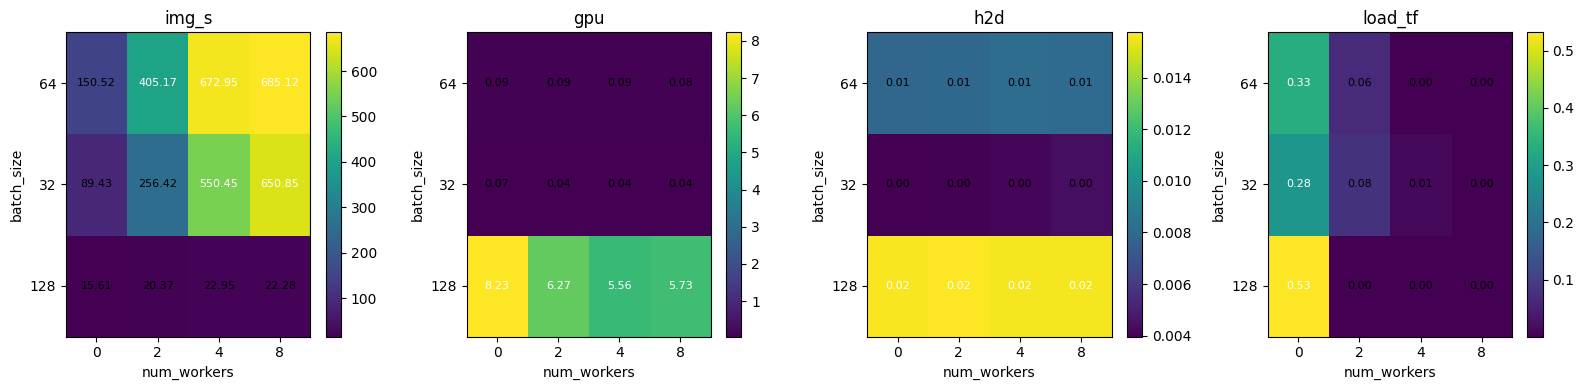

In [13]:
# plot heatmap(s) from `heat` produced by build_profile_heatmap_data
metrics = heat['metrics']
x_vals = heat['x_values']
y_vals = heat['y_values']
matrices = heat['matrices']

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    mat = np.array(matrices[metric])
    im = ax.imshow(mat, cmap='viridis', aspect='auto', origin='lower')
    ax.set_title(metric)
    ax.set_xlabel(heat['x_param'])
    ax.set_xticks(np.arange(len(x_vals)))
    ax.set_xticklabels(x_vals)
    ax.set_ylabel(heat['y_param'])
    ax.set_yticks(np.arange(len(y_vals)))
    ax.set_yticklabels(y_vals)
    # annotate
    th = (mat.max() + mat.min()) / 2.0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center',
                    color='white' if mat[i, j] > th else 'black', fontsize=8)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

#### Validation Pipeline

In [9]:
batch_size_list = [32, 64, 128, 256]
num_worker_list = [2, 4, 8]

from src.utils import profile_dataloader_grid_search, build_profile_heatmap_data

search_out = profile_dataloader_grid_search(
    ds=ds,
    model=model.to(DEVICE),
    device=DEVICE,
    param_grid={
        "batch_size": [32, 64, 128],
        "num_workers": [0, 2, 4, 8],
        "prefetch_factor": [2, 4],
    },
    mode="val",
    steps=100,
    warmup=20,
)

heat = build_profile_heatmap_data(
    search_out,
    x_param="num_workers",
    y_param="batch_size",
    metrics=["img_s", "gpu", "h2d", "load_ft"],  # load_ft alias -> load_tf
)


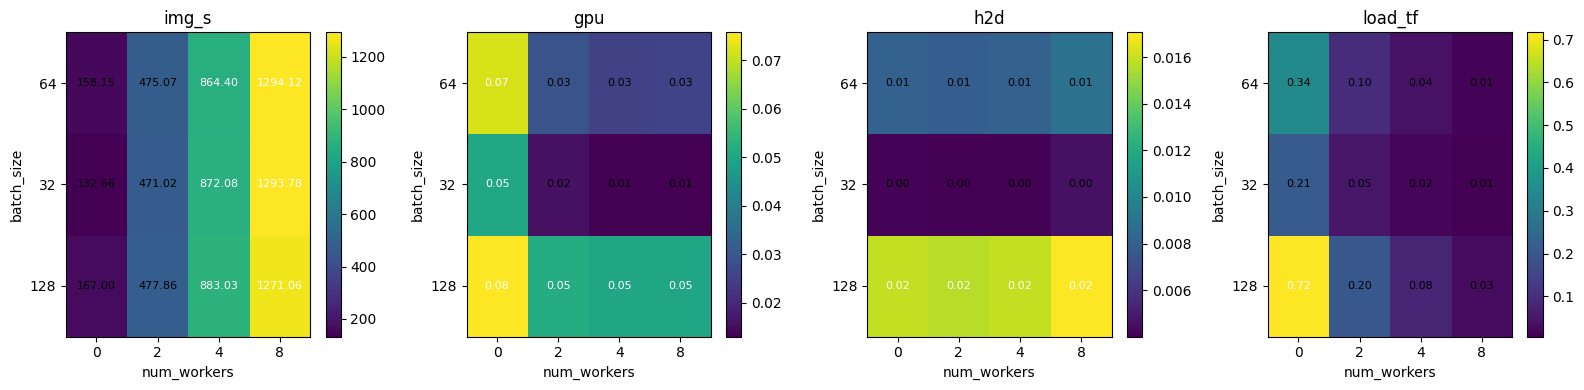

In [11]:
# plot heatmap(s) from `heat` produced by build_profile_heatmap_data
metrics = heat['metrics']
x_vals = heat['x_values']
y_vals = heat['y_values']
matrices = heat['matrices']

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4))
if len(metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, metrics):
    mat = np.array(matrices[metric])
    im = ax.imshow(mat, cmap='viridis', aspect='auto', origin='lower')
    ax.set_title(metric)
    ax.set_xlabel(heat['x_param'])
    ax.set_xticks(np.arange(len(x_vals)))
    ax.set_xticklabels(x_vals)
    ax.set_ylabel(heat['y_param'])
    ax.set_yticks(np.arange(len(y_vals)))
    ax.set_yticklabels(y_vals)
    # annotate
    th = (mat.max() + mat.min()) / 2.0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center',
                    color='white' if mat[i, j] > th else 'black', fontsize=8)
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

The results showed that optimal pipeline throupgut can be achieved with `num_workers=8` and `batch_size=64`

### Cross Validation

In [8]:
n_splits = 5
test_size = 0.2
skf = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=SEED)

In [10]:
class CV_Trainer():
    def __init__(self, model, idx_train, y_train, ds, ds_aug, cv, loss_fn, optim) -> None:
        self.model_cls, self.model_params = model        
        self.idx_train = np.asarray(idx_train)
        self.y_train = y_train
        self.spliter, self.split_groups = cv        
        self.loss_fn = loss_fn
        self.optimizer, self.optim_params = optim
        self.hist = []
        self.oof_y_pred = None
        self.ds = ds
        self.ds_aug = ds_aug
        pass
    def train(self, epochs, tr_bs, val_bs=None, tr_nw=4, val_nw=4):
        self.hist = []
        self.oof_y_pred = np.zeros_like(self.y_train)
        if self.split_groups is not None:
            fold_pbar = tqdm(self.spliter.split(self.idx_train, self.y_train, groups=self.split_groups), total=self.spliter.get_n_splits(), desc="CV folds")            
        else:
            fold_pbar = tqdm(self.spliter.split(self.idx_train, self.y_train), total=self.spliter.get_n_splits(), desc="CV folds")
        
        if val_bs is None:
            val_bs = tr_bs

        for fold, (tr_idx, val_idx) in enumerate(fold_pbar):
            fold_hist = {'loss':[], 'val_loss':[]}
            fold_tr_idx = self.idx_train[tr_idx]
            fold_val_idx = self.idx_train[val_idx]
            fold_tr_dl = DataLoader(Subset(self.ds_aug, fold_tr_idx), batch_size=tr_bs, num_workers=tr_nw, persistent_workers=True)
            fold_val_dl = DataLoader(Subset(self.ds, fold_val_idx), batch_size=val_bs, num_workers=val_nw, persistent_workers=True)
            model = self.model_cls(**self.model_params).to(DEVICE)
            loss_fn = self.loss_fn()
            optim = self.optimizer(model.parameters(), **self.optim_params)
            for e in range(epochs):    
                model.train()
                tr_tot_bs = 0                
                total_loss = 0                 
                for x, y in tqdm(fold_tr_dl, desc=f"train e{e+1}", leave=False):
                    x = x.to(DEVICE, non_blocking=True)
                    y = y.to(DEVICE, non_blocking=True)
                    optim.zero_grad(set_to_none=True)
                    logits = model(x)            
                    loss = loss_fn(logits, y.long())
                    bs = x.size(0)
                    tr_tot_bs += bs
                    total_loss += loss.item() * bs
                    train_loss = total_loss / tr_tot_bs
                    loss.backward()
                    optim.step()
                fold_hist['loss'].append(train_loss)    
                # validation
                model.eval()
                val_tot_bs = 0
                total_val_loss = 0
                
                with torch.inference_mode():
                    for x, y in tqdm(fold_val_dl, desc=f"val e{e+1}", leave=False):
                        x = x.to(DEVICE, non_blocking=True)
                        y = y.to(DEVICE, non_blocking=True)
                        logits = model(x)            
                        loss = loss_fn(logits, y.long())
                        bs = x.size(0)
                        val_tot_bs += bs
                        total_val_loss += loss.item() * bs
                        val_loss = total_val_loss / val_tot_bs
                fold_hist['val_loss'].append(val_loss)         
            self.hist.append(fold_hist)
            model.eval()            
            # collect predictions per batch and concatenate properly
            fold_y_preds = []
            with torch.inference_mode():
                for x, y in tqdm(fold_val_dl, desc=f"oof prediction", leave=False):
                    x = x.to(DEVICE, non_blocking=True)
                    # get predicted class ids on CPU as numpy array
                    preds = torch.argmax(model.predict_proba(x), dim=1).to('cpu').numpy()
                    fold_y_preds.append(preds)
            if len(fold_y_preds) > 0:
                fold_y_pred = np.concatenate(fold_y_preds, axis=0)
            else:
                fold_y_pred = np.array([], dtype=int)
            self.oof_y_pred[val_idx] = fold_y_pred
            del fold_tr_dl, fold_val_dl            
            del model
            del optim
            gc.collect()
            torch.cuda.empty_cache()
        
        return self.hist, self.oof_y_pred

In [11]:
loss_fn = torch.nn.CrossEntropyLoss
epochs = 20 
tr_bs = 64 
val_bs = 128
tr_nw = 4
val_nw = 4
cv_trainer = CV_Trainer([CNN_Clf, {'num_class': 2}], idx_train, y_train, ds, ds_aug, [skf, None], loss_fn, [torch.optim.Adam, {"lr": 1e-3, "weight_decay": 1e-4}])

In [ ]:
hist, oof_preds = cv_trainer.train(epochs, tr_bs, val_bs, tr_nw, val_nw)

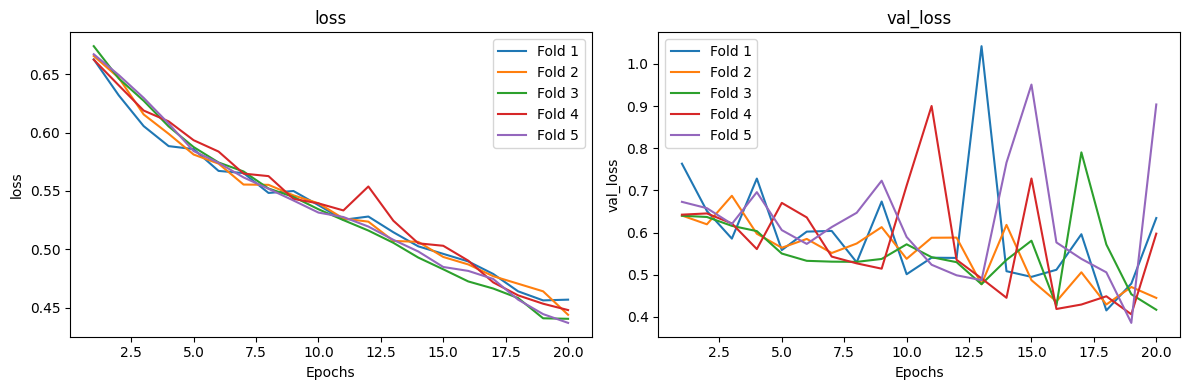

best val loss of fold 1 at epochs : 18, val_loss = 0.4155742772039911
best val loss of fold 2 at epochs : 18, val_loss = 0.42958856557529834
best val loss of fold 3 at epochs : 20, val_loss = 0.41711593648171874
best val loss of fold 4 at epochs : 19, val_loss = 0.4063145948688078
best val loss of fold 5 at epochs : 19, val_loss = 0.38600387529559166
Val loss :0.4109 ± 0.0145
Train loss :0.4450 ± 0.0067


In [21]:
plot_hist(hist)
min_val_losses = []
min_tr_losses = []
for i, f in enumerate(hist):
    print(f'best val loss of fold {i + 1} at epochs : {np.argmin(f['val_loss']) + 1}, val_loss = {np.min(f['val_loss'])}')
    min_val_losses.append(np.min(f['val_loss']))
    min_tr_losses.append(np.min(f['loss']))
print(f'Val loss :{np.mean(min_val_losses):.4f} ± {np.std(min_val_losses):.4f}')
print(f'Train loss :{np.mean(min_tr_losses):.4f} ± {np.std(min_tr_losses):.4f}')



The CV only runs with 20 epochs for each fold due to the long training time, but it conveys several helpful signals:
* The model is trainable with current dataset. 
* There is no red flag issue in the pipeline.
* The validation loss generally decreases over epoch, despite some noticeable spikes. 

The next step is a test train on the baseline model with more epochs to evaluate the baseline performance.

### Baseline Model Test Train

* Use a simple split for saving time
* Allow more epochs to see if the best performace is acceptable. (compare to dummy model)

In [31]:
# setup
epochs = 200
batch_size = 64
val_batch_size = 128
num_workers = 4
model = CNN_Clf()
optim = torch.optim.Adam(model.parameters())
hist = [{'loss':[], 'val_loss':[]}]

tr_idx, val_idx, y_tr, y_val = train_test_split(idx_train, y_train, test_size=0.2, random_state=SEED, shuffle=True, stratify=y_train)
ds_train = Subset(ds_aug, tr_idx)
ds_val = Subset(ds, val_idx)

tr_dl = DataLoader(ds_train, batch_size, shuffle=True, num_workers=num_workers,          # try 2/4/8
    pin_memory=True,
    persistent_workers=True)
val_dl = DataLoader(ds_val, val_batch_size, shuffle=False, num_workers=num_workers,          # try 2/4/8
    pin_memory=True,
    persistent_workers=True)

# cnn_clf = CNN_Clf(2).to(DEVICE)
# optim = torch.optim.Adam(cnn_clf.parameters(), lr=0.001) 
loss_fn = torch.nn.CrossEntropyLoss()


In [ ]:
# main loop
epoch_pbar = tqdm(range(epochs), desc='epoch', leave=False)
for e in epoch_pbar:
    epoch_pbar.set_description(f'epoch {e+1}/{epochs}')
    cnn_clf.train()
    fold_tr_size = 0
    fold_val_size = 0
    total_loss = 0 
    total_val_loss = 0
    for x, y in tqdm(tr_dl, desc=f"train e{e+1}", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optim.zero_grad(set_to_none=True)
        logits = cnn_clf(x)            
        loss = loss_fn(logits, y.long())
        bs = x.size(0)
        fold_tr_size += bs
        total_loss += loss.item() * bs
        train_loss = total_loss / fold_tr_size
        loss.backward()
        optim.step()
    hist[0]['loss'].append(train_loss)    
    # validation
    cnn_clf.eval()
    with torch.inference_mode():
        for x, y in tqdm(val_dl, desc=f"val e{e+1}", leave=False):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            logits = cnn_clf(x)
            loss = loss_fn(logits, y.long())
            bs = x.size(0)
            fold_val_size += bs
            total_val_loss += loss.item() * bs
            val_loss = total_val_loss / fold_val_size    
    hist[0]['val_loss'].append(val_loss)
    epoch_pbar.set_postfix(loss=f"{train_loss:.4f}", val_loss=f"{val_loss:.4f}")
    if (e + 1) % 20 == 0:
        print(f'epoch: {e + 1}: train loss: {train_loss:.4f}, val_loss={val_loss:.4f}')
        save_checkpoint(
            ckpt_path=ckpt_path,
            model=cnn_clf,
            optimizer=optim,
            epoch=e + 1,
            hist=hist,
            extra={
                "seed": SEED,
                "batch_size": batch_size,
                "val_batch_size": val_batch_size,
                "lr": 0.001,
            },
            )

# dummy model
dummy_model = DummyClassifier(strategy='uniform')
dummy_model.fit(tr_idx, y_tr)
proba = dummy_model.predict_proba(tr_idx)
dummy_loss = log_loss(y_tr, proba, labels=[0,1])

# save model
timestr = time.strftime("%Y%m%d-%H-%M-%S")
torch.save(cnn_clf.state_dict(), MODELS_DIR / f'cnn_clf_{timestr}.pth')


#### Model Test Train Results
Load saved training result and model for performance evaluation

In [ ]:
with open(MODELS_DIR / 'hist_20260212-13-53-03.json', 'r') as f:
    hist_1 = json.load(f)

cnn_clf = CNN_Clf(2).to(DEVICE)
cnn_clf.load_state_dict(torch.load(MODELS_DIR / 'cnn_clf.pth'))
hist_1[0]['loss'].extend(hist[0]['loss'])
hist_1[0]['val_loss'].extend(hist[0]['val_loss'])


<All keys matched successfully>

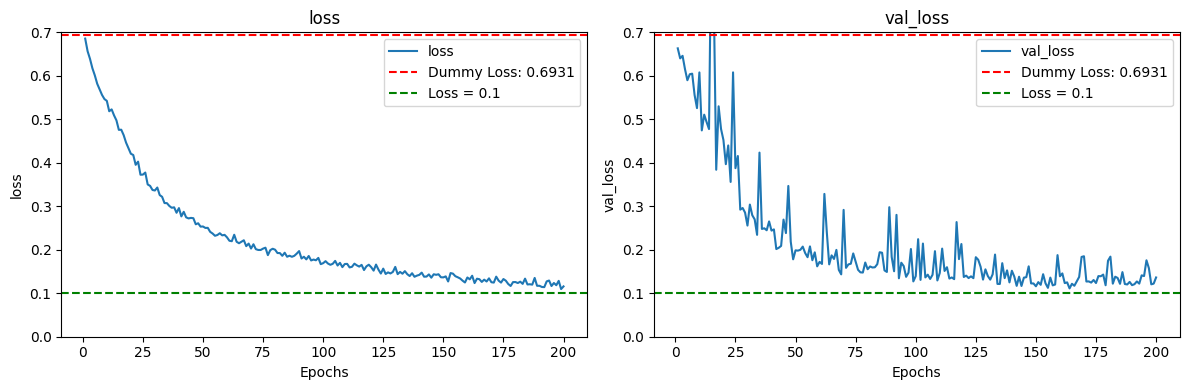

In [29]:
fig, ax = plot_hist(hist_1, show=False)
ax[0].axhline(y=dummy_loss, color='red', linestyle='--', label=f'Dummy Loss: {dummy_loss:.4f}')
ax[1].axhline(y=dummy_loss, color='red', linestyle='--', label=f'Dummy Loss: {dummy_loss:.4f}')
ax[0].axhline(y=0.1, color='green', linestyle='--', label=f'Loss = 0.1')
ax[1].axhline(y=0.1, color='green', linestyle='--', label=f'Loss = 0.1')
ax[0].set_ylim(0, 0.7)
ax[1].set_ylim(0, 0.7)
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()


The loss curves indicate that the baseline model beats the random guess, and its performace is close 0.1 after 200 epochs.

inference:   0%|          | 0/20 [00:00<?, ?it/s]

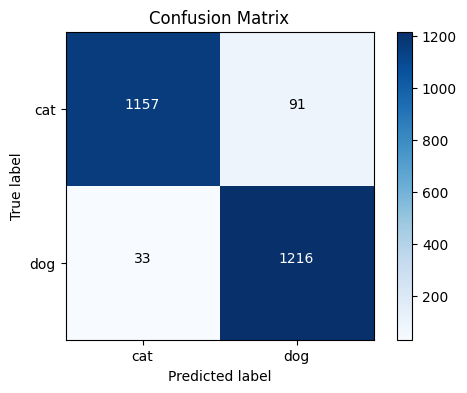

              precision    recall  f1-score   support

         cat       0.97      0.93      0.95      1248
         dog       0.93      0.97      0.95      1249

    accuracy                           0.95      2497
   macro avg       0.95      0.95      0.95      2497
weighted avg       0.95      0.95      0.95      2497



In [38]:
cnn_clf.eval()
y_pred = torch.tensor(np.empty_like([])).to(DEVICE)
y_val = torch.tensor(np.empty_like([])).to(DEVICE)
with torch.inference_mode():
    for x, y in tqdm(val_dl, desc=f"inference", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        y_pred = torch.concat((y_pred, cnn_clf.predict_id(x)))
        y_val = torch.concat((y_val, y))

y_pred_np = y_pred.to('cpu').detach().numpy().astype('int')
y_val_np = y_val.to('cpu').detach().numpy().astype('int')
           
plot_confusion_matrix_and_report(y_val_np, y_pred_np, target_names=['cat', 'dog'])

* The f1-score of current baseline model is 0.95, which is on par with basic dogs & cats problem on the Kaggle.
* Next stage: transfer learning using RestNet model and ViT
